**Image Processing  - Mobina Vafaei 25120465 - Best Model: SVM (Model 5)**

##**Load Data**

In [ ]:
# Extract the .rar file
!apt-get -y install unrar

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [43]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from random import randint
from random import seed
from tqdm import tqdm

In [48]:
# Image Processing & Feature Extraction
import cv2
from skimage.feature import hog, local_binary_pattern

In [47]:
# Machine Learning
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score

In [4]:
RANDOM_SEED = 100

In [11]:
# extract .rar file
!unrar x "/content/train_images.rar"
!unrar x "/content/test_images.rar"

Streaming output truncated to the last 5000 lines.
Extracting  train_images/6406.jpg                                         60%  OK 
Extracting  train_images/6407.jpg                                         60%  OK 
Extracting  train_images/6408.jpg                                         60%  OK 
Extracting  train_images/6409.jpg                                         60%  OK 
Extracting  train_images/641.jpg                                          60%  OK 
Extracting  train_images/6410.jpg                                         60%  OK 
Extracting  train_images/6411.jpg                                         60%  OK 
Extracting  train_images/6412.jpg                                         60%  OK 
Extracting  train_images/6413.jpg                                         60%  OK 
Extracting  train_images/6414.jpg                                         60%  OK 
Extracting  train_images/6415

In [12]:
# load training data
df_train = pd.read_csv(os.path.join("/content/train.csv"))

# summarise the details
print(f'Number of entries: {len(df_train)}')
df_train.head()

Number of entries: 10000


,id,label
0,1,cat
1,2,dog
2,3,cat
3,4,cat
4,5,cat


In [6]:
# load testing data
df_test = pd.read_csv(os.path.join("/content/test.csv"))

# summarise the details
print(f'Number of entries: {len(df_test)}')
df_test.head()

Number of entries: 1000


,id
0,1
1,2
2,3
3,4
4,5


<Axes: xlabel='label', ylabel='count'>

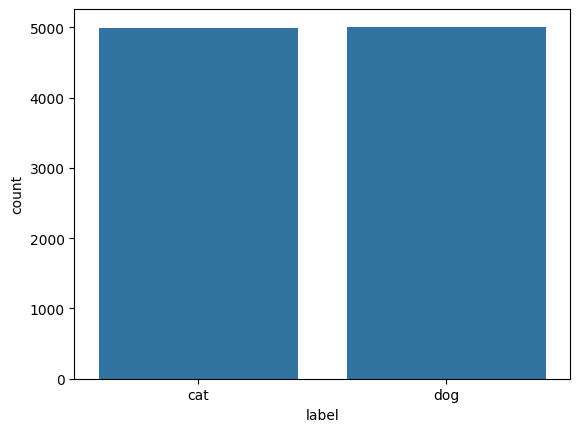

In [7]:
# Summarise label details in training data
sns.countplot(x=df_train['label'])

In [9]:
# method to load images in a folder
def load_images(ids, folder_path, dim=None):
  images = []
  for id in tqdm(ids):
    image_path = os.path.join(folder_path, f'{id}.jpg')
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)


# checking for loaded correctly
    if img is None:
      print("Missing:", image_path)
      continue

# resize image if target dimension is provided
    if dim is not None:
      img = cv2.resize(img, dim, interpolation=cv2.INTER_AREA)
    images.append(img)
  return images

In [13]:
base_dim = (200, 200)

# load train images
train_image_folder = os.path.join('/content/train_images')
train_images = load_images(df_train['id'], train_image_folder, base_dim)
print(f'Number of training images loaded: {len(train_images)}')

100%|██████████| 10000/10000 [00:17<00:00, 565.39it/s]

Number of training images loaded: 10000


In [14]:
base_dim = (200, 200)

# load test images
test_image_folder = os.path.join("/content/test_images")
test_images = load_images(df_test['id'], test_image_folder, base_dim)
print(f'Number of testing images loaded: {len(test_images)}')

100%|██████████| 1000/1000 [00:01<00:00, 556.59it/s]

Number of testing images loaded: 1000


##**Preprocessing and model generation**

In [27]:
# calculate evaluation results
def evaluate(actuals, predictions, class_names):

  # calculate accuracy
  accuracy = metrics.accuracy_score(actuals, predictions)
  print(f'Accuracy: {accuracy}')

  # calculate F1-score
  f1 = metrics.f1_score(actuals, predictions, average='weighted')
  print(f'F1-score: {f1}')

  # plot confusion matrix
  confusion_matrix = metrics.confusion_matrix(actuals, predictions, labels=class_names)
  disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=class_names)
  disp.plot()
  plt.show()

###**SVM**

In [ ]:
# SVM classifier
def get_svm_predictions(X_train, X_val, y_train, y_val):

  # build model
  clf = svm.SVC(random_state=RANDOM_SEED)
  clf.fit(X_train, y_train)

  # Make predictions on test data
  y_pred = clf.predict(X_val)

  # evalution
  evaluate(y_val, y_pred, clf.classes_)
  return clf

###**Model 1**


*   Preprocessing - gray scaling
*   Features - image vector



In [ ]:
def get_features_m1(images):

  features_list = []
  for img in images:
    # image preprocessing - gray scaling
    img_grayscaled = img

    # image vectorisation
    features = img_grayscaled.flatten()

    features_list.append(features)

  features_list = np.array(features_list)
  return features_list

In [ ]:
# feature extraction
features_train = get_features_m1(train_images)
print(features_train.shape)

(10000, 40000)


In [ ]:
# data split for train and validation
X_train, X_val, y_train, y_val = train_test_split(features_train, df_train['label'], test_size=0.3, random_state=RANDOM_SEED)

Accuracy: 0.64
F1-score: 0.6398001153180858


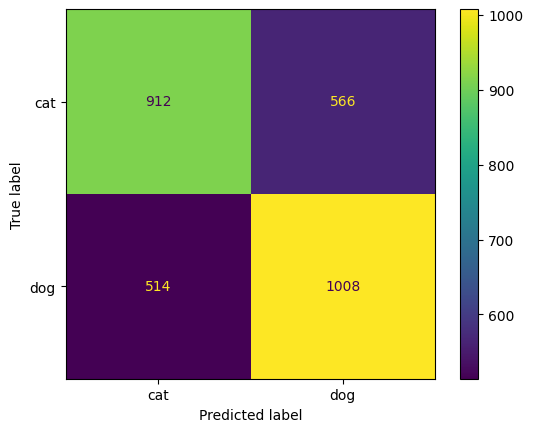

In [ ]:
# train model 1
m1 = get_svm_predictions(X_train, X_val, y_train, y_val)

In [ ]:
# feature extraction - test data
features_test = get_features_m1(test_images)
print(features_test.shape)

# get model predictions
predictions = m1.predict(features_test)
print(predictions)

(1000, 4096)
['dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog'
 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'cat'
 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'dog'
 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat'
 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog'
 'dog' 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat'
 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat'
 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog'
 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat'
 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'dog'
 'cat' 'dog' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'cat'
 'dog' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat'
 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog'
 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' '

###**Model 2**


*   Preprocessing - gray scaling, smoothing
*   Features - image vector



Image Id: 2386
Image Id: 7528
Image Id: 7453
Image Id: 2863
Image Id: 6439


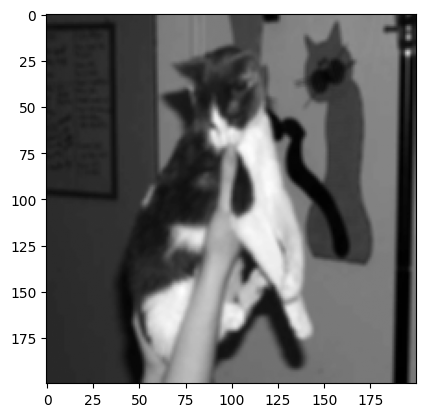

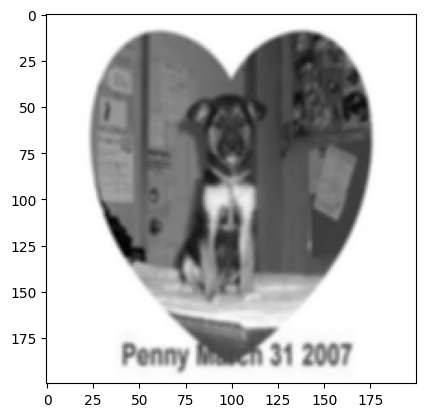

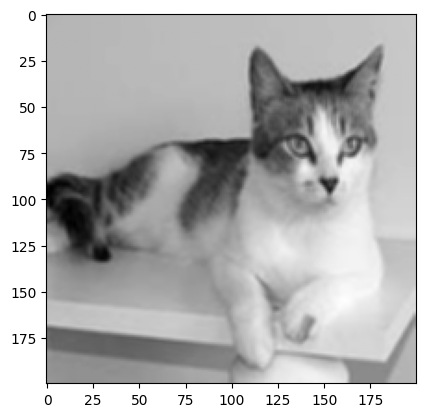

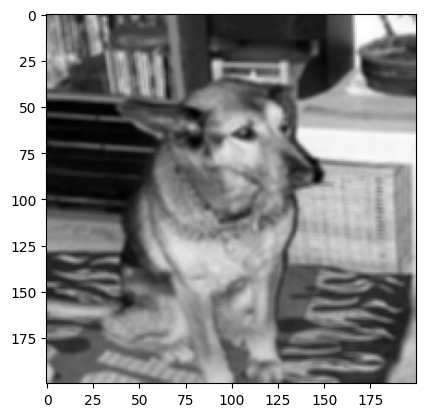

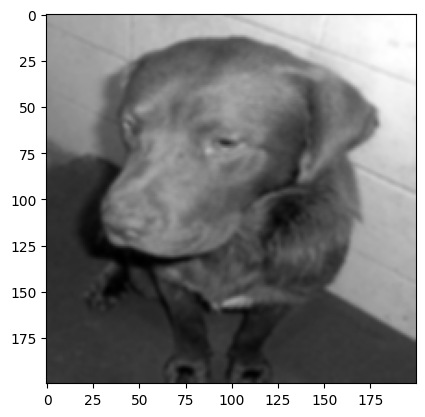

In [ ]:
seed(RANDOM_SEED)
sample_images = []

for i in range(5):
  value = randint(0, len(train_images)-1)
  print(f'Image Id: {value}')
  sample_images.append(train_images[value])

# apply preprocessing
for img in sample_images:
  img_grayscaled = img
  img_blurred = cv2.GaussianBlur(img_grayscaled,(3,3), 2)

  plt.imshow(img_blurred, cmap='gray')
  plt.show()

In [ ]:
# Model 2
def get_features_m2(images):

  features_list = []
  for img in images:
    # image preprocessing - gray scaling + smoothing
    img_grayscaled = img
    img_blurred = cv2.GaussianBlur(img_grayscaled, (3,3), 2)

    # image vectorisation
    features = img_blurred.flatten()

    features_list.append(features)

  features_list = np.array(features_list)
  return features_list

In [ ]:
# feature extraction
features_train = get_features_m2(train_images)
print(features_train.shape)

(10000, 40000)


In [ ]:
# data split for train and validation
X_train, X_val, y_train, y_val = train_test_split(features_train, df_train['label'], test_size=0.3, random_state=RANDOM_SEED)

Accuracy: 0.639
F1-score: 0.6388498180302967


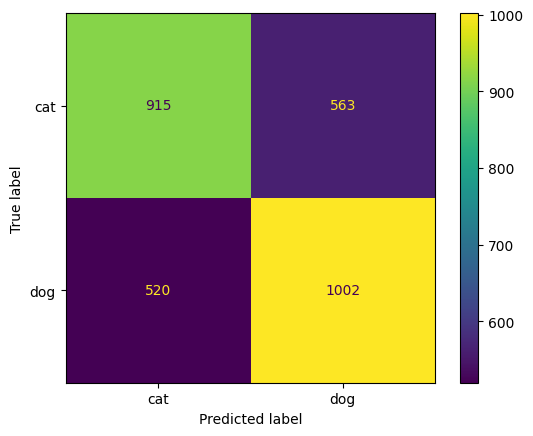

In [ ]:
# train model 2
m2 = get_svm_predictions(X_train, X_val, y_train, y_val)

In [ ]:
# feature extraction - test data
features_test = get_features_m2(test_images)
print(features_test.shape)

# get model predictions
predictions = m2.predict(features_test)
print(predictions)

(1000, 40000)
['dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'cat' 'dog'
 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'cat'
 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'dog'
 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat'
 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog'
 'dog' 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat'
 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat'
 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog'
 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat'
 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'dog' 'cat' 'dog' 'dog'
 'cat' 'dog' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'cat'
 'dog' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat'
 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog'
 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 

###**Model 3**


*   Preprocessing - gray scaling
*   Features - edge map to vector (Canny edge detection )



In [ ]:
# method to get image features
def get_features_m3(images):

  features_list = []
  for img in images:
    # image preprocessing
    img_grayscaled = img

    edges_canny = cv2.Canny(img_grayscaled, 100, 200)
    features = edges_canny.flatten()

    features_list.append(features)

  features_list = np.array(features_list)
  return features_list

In [ ]:
# feature extraction
features_train = get_features_m3(train_images)
print(features_train.shape)

(10000, 40000)


In [ ]:
# data split for train and validation
X_train, X_val, y_train, y_val = train_test_split(features_train, df_train['label'], test_size=0.3, random_state=RANDOM_SEED)

Accuracy: 0.6053333333333333
F1-score: 0.6038979259523385


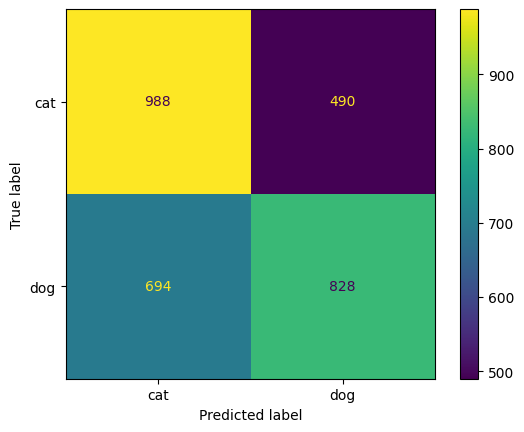

In [ ]:
# train model 3
m3 = get_svm_predictions(X_train, X_val, y_train, y_val)

In [ ]:
# feature extraction - test data
features_test = get_features_m3(test_images)
print(features_test.shape)

# get model predictions
predictions = m3.predict(features_test)
print(predictions)

(1000, 40000)
['dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog'
 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'dog' 'cat'
 'dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat'
 'dog' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat'
 'cat' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog'
 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'dog' 'cat' 'dog' 'cat'
 'cat' 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'dog'
 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat'
 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog'
 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'dog' 'cat' 'dog' 'dog' 'dog' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog'
 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat'
 'cat' 'dog' 'dog' 'dog' 'cat' 'dog' 

###**Model 4**


*   Preprocessing - gray scaling
*   Features - HOG feature



In [ ]:
# Model 4
def get_features_m4(images):

  features_list = []
  for img in images:
    # image preprocessing
    img_grayscaled = img

    # Resize image if necessary
    img_resized = cv2.resize(img_grayscaled, (64, 128))

    features, hog_image = hog(img_resized, orientations=9, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), visualize=True)

    features_list.append(features)

  features_list = np.array(features_list)
  return features_list

In [ ]:
# feature extraction
features_train = get_features_m4(train_images)
print(features_train.shape)

(10000, 3780)


In [ ]:
# data split for train and validation
X_train, X_val, y_train, y_val = train_test_split(features_train, df_train['label'], test_size=0.3, random_state=RANDOM_SEED)

Accuracy: 0.7333333333333333
F1-score: 0.733128440084139


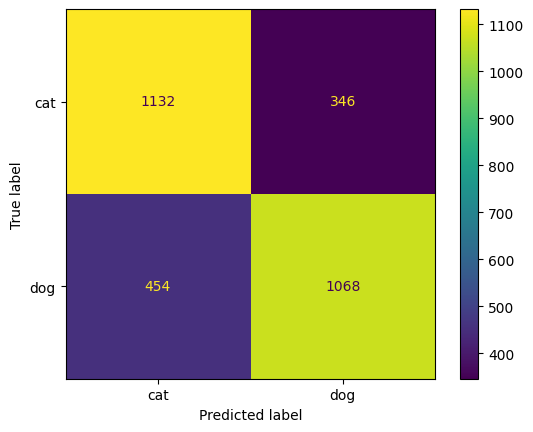

In [ ]:
# train model
m4 = get_svm_predictions(X_train, X_val, y_train, y_val)

In [ ]:
# feature extraction - test data
features_test = get_features_m4(test_images)
print(features_test.shape)

# get model predictions
predictions = m4.predict(features_test)
print(predictions)

(1000, 3780)
['dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog'
 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'cat' 'cat' 'dog'
 'dog' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat'
 'cat' 'dog' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog'
 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat'
 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat'
 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat'
 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat'
 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog'
 'cat' 'dog' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'dog' 'cat'
 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'dog' 'cat' 'dog' 'cat'
 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog'
 'cat' 'cat' 'dog' 'cat' 'dog' 'cat' '

### **Model M5 / Best Model**

- Preprocessing - gray scaling - smoothing
- Features - HOG feature

In [22]:
# SVM classifier - Model 5
def get_svm_predictions_model5(X_train, X_val, y_train, y_val):

  # build model
  clf = svm.SVC(kernel='rbf', gamma='scale', C=10)
  clf.fit(X_train, y_train)

  # Make predictions on test data
  y_pred = clf.predict(X_val)

  # evalution
  evaluate(y_val, y_pred, clf.classes_)
  return clf

In [23]:
# Model 5
def get_features_m5(images):

  features_list = []
  for img in images:
    # image preprocessing
    img_grayscaled = img

    # Resize image if necessary
    img_resized = cv2.resize(img_grayscaled, (128, 128))
    img_blurred = cv2.GaussianBlur(img_resized,(3,3),0)
    img_hist = cv2.equalizeHist(img_blurred)

    features = hog(img_hist, orientations=9, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), block_norm='L2-Hys')

    features_list.append(features)

  features_list = np.array(features_list)
  return features_list

In [24]:
# feature extraction
features_train = get_features_m5(train_images)
print(features_train.shape)

(10000, 8100)


In [19]:
# data split for train and validation
X_train, X_val, y_train, y_val = train_test_split(features_train, df_train['label'], test_size=0.3, random_state=42, stratify=df_train["label"])

Accuracy: 0.751
F1-score: 0.7509843122312992


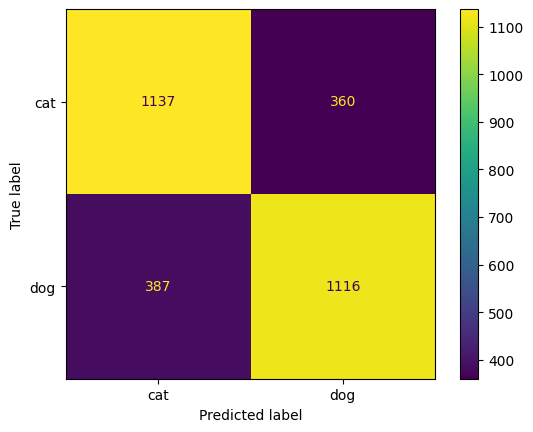

In [20]:
# train model
m5 = get_svm_predictions_model5(X_train, X_val, y_train, y_val)

In [21]:
# feature extraction - test data
features_test = get_features_m5(test_images)
print(features_test.shape)

# get model predictions
predictions = m5.predict(features_test)
print(predictions)

(1000, 8100)
['dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog'
 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat'
 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'cat' 'cat' 'dog'
 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat'
 'dog' 'dog' 'cat' 'dog' 'cat' 'dog' 'dog' 'dog' 'cat' 'cat' 'cat' 'cat'
 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'cat'
 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat'
 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat'
 'cat' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat'
 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'cat'
 'cat' 'dog' 'cat' 'dog' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat'
 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog' 'cat'
 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog'
 'cat' 'cat' 'dog' 'cat' 'cat' 'cat' '

### **Model M6**

- Preprocessing - gray scaling, smoothing
- Features - HOG
- SVM Hyperparameters

In [55]:
# SVM classifier - Model 6
def get_svm_predictions_model6(X_train, X_val, y_train, y_val):

  # Feature scaling
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_val_scaled = scaler.transform(X_val)

  # Hyperparameters
  param_grid = {
      'C': [0.1, 1, 5, 10, 20],
      'gamma': ['scale'],
      'kernel': ['rbf']
  }

  # GridSearch
  grid = GridSearchCV(
      SVC(),
      param_grid,
      cv=3,
      scoring='f1_macro',
      verbose=2,
      n_jobs=-1
  )
  grid.fit(X_train_scaled, y_train)
  print("Best Parameters:", grid.best_params_)
  best_model = grid.best_estimator_


  # Make predictions on test data
  y_pred = best_model.predict(X_val_scaled)
  evaluate(y_val, y_pred, best_model.classes_)

  # evalution
  evaluate(y_val, y_pred, best_model.classes_)
  return best_model, scaler

In [56]:
# Model 6
def get_features_m6(images):

  features_list = []
  for img in images:
    # image preprocessing
    img_grayscaled = img

    # Resize image if necessary
    img_resized = cv2.resize(img_grayscaled, (128, 128))
    img_blurred = cv2.GaussianBlur(img_resized,(3,3),0)
    img_hist = cv2.equalizeHist(img_blurred)

    # hog feature
    hog_features, hog_image = hog(img_hist, orientations=9, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), visualize=True)

    features_list.append(hog_features)

  features_list = np.array(features_list)
  return features_list

In [57]:
# feature extraction
features_train = get_features_m6(train_images)
print(features_train.shape)

KeyboardInterrupt: 

In [ ]:
# data split for train and validation
X_train, X_val, y_train, y_val = train_test_split(features_train, df_train['label'], test_size=0.3, random_state=RANDOM_SEED, stratify=df_train['label'])

In [ ]:
m6, scaler = get_svm_predictions_model6(X_train, X_val, y_train, y_val)

In [ ]:
features_test = get_features_m6(test_images)
features_test = scaler.transform(features_test)

predictions = m6.predict(features_test)
print(predictions)